In [9]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz
from joblib import Parallel, delayed
import numpy as np
import kibble_zurek as kz
from itertools import combinations
from collections import Counter
import adprox

In [7]:
taus = logspace(-1,3,250)
states = [state(512,tau,tau) for tau in tqdm(taus)]

100%|██████████| 250/250 [04:12<00:00,  1.01s/it]


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Text(0.5, 1.0, 'Ground state defects compared to long tau approximation (dotted) for $P_n$, L =512')

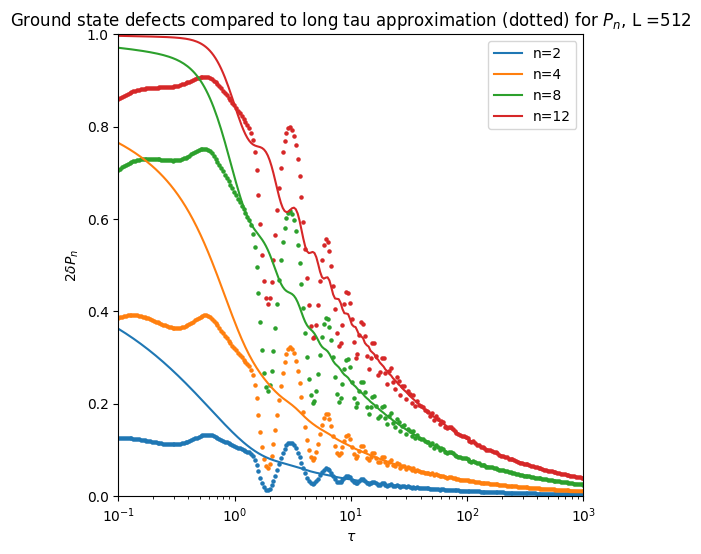

In [32]:
ns = [2,4,8,12]
plt.figure(figsize=(6,6))
for n in ns:
    Pexact = array([Px(n,s) for s in states])
    Papprox= array([adprox.P_n(n,tau) for tau in taus])

    plot(taus,1-Pexact*2,label=f"n={n}")
    scatter(taus,1-Papprox*2,s=5)
xlim(taus[0],taus[-1])
xscale("log")
#loglog()
ylim(0,1)
legend()
xlabel(r"$\tau$")
ylabel(r"$2 \delta P_n$")
title(rf"Ground state defects compared to long tau approximation (dotted) for $P_n$, L ={512}")
#savefig("figures/Convergence_of_Approximation_defect_strings.png")